<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Bahcall Probability - Solar Neutrino Survival Probabilities and Production Spectra
---

This notebook is a companion to `Bahcall_EDA.ipynb`, focused specifically on
**survival/transition probability** data and the associated **undistorted
production energy spectra**, downloaded from John Bahcall's public
**[Solar Neutrino Software and Data](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)**
page and stored in the same directory, `data/external/Bahcall`.

All of the probability tables here are $P_{ee}(E)$: the electron-neutrino
survival probability as a function of neutrino energy, for a given choice of
oscillation parameters, **not** a function of radius inside the Sun. The
"Day" column of the MSW tables (Section 4) is the closest available
equivalent to "probability at the solar surface": it is the survival
probability with **no** Earth regeneration, i.e. immediately after leaving
the Sun and propagating through vacuum to a day-side detector -- distinct
from the "Night" column, which includes the Earth matter effect studied
throughout this project's own `medium.earth` package.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Dataset-and-Physics-Context) | **Dataset and Physics Context**: source, files, physics, references |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Raw-Data-Inventory) | **Raw Data Inventory** |
| [4](#4.-MSW-Survival-Probabilities-(LMA-SMA-LOW)) | **MSW Survival Probabilities (LMA/SMA/LOW)**: day/solar-surface (4.1), Earth regeneration (4.2) |
| [5](#5.-Illustrative-8B-and-CNO-Survival-Probability-Sets) | **Illustrative 8B and CNO Survival Probability Sets**: 8B parameter sets (5.1), CNO by species (5.2) |
| [6](#6.-Undistorted-Neutrino-Production-Spectra) | **Undistorted Neutrino Production Spectra**: 8B (6.1), pp (6.2), CNO and hep (6.3) |
| [7](#7.-Combining-Production-Spectrum-and-Survival-Probability) | **Combining Production Spectrum and Survival Probability** |
| [8](#8.-Summary) | **Summary** |


## 0. Dataset and Physics Context

### 0.1 Source of the Data

The files analysed here come from John Bahcall's public page
**[Solar Neutrino Software and Data](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)**
(`sns.ias.edu/~jnb`, Institute for Advanced Study), specifically the
`MSWsurvival`, `B8survival`, `CNOsurvival`, `B8spectrum`, `PPenergyspectrum`,
`CNOspectra`, and `Hepspectrum` `Export` subdirectories. The local directory
`data/external/Bahcall` contains, in addition to the standard-model files
analysed in `Bahcall_EDA.ipynb`:

| Local file | Content |
|---|---|
| `PNU98LMA.dat`, `PNU98SMA.dat`, `PNU98LOW.dat` | $P_{ee}(E)$ for the LMA/SMA/LOW MSW solutions: day, day+night average, night |
| `b8survival.tab` | Seven illustrative $P_{ee}(E)$ curves (small-mixing-angle region), averaged over the 8B production region |
| `cnosurvival.tab` | $P_{ee}(E)$ for pp, 8B, 13N, 15O sources, for one all-CNO MSW parameter point |
| `b8spectrum.txt` | Undistorted 8B production spectrum, best estimate $\pm3\sigma$ |
| `ppenergytab` | Undistorted pp production spectrum (wrapped 4-column table) |
| `n13.dat`, `o15.dat`, `f17.dat` | Undistorted CNO-cycle production spectra |
| `hepspectrum.dat` | Undistorted hep production spectrum |

The spectrum files are explicitly labelled **undistorted** on Bahcall's data
page, a term worth making precise:

- **Undistorted spectrum** ($dN/dE$ in Section 6): the neutrino energy
  spectrum fixed purely by the production reaction's own decay/fusion
  kinematics (e.g. the $^8$B $\beta^+$ decay endpoint and shape), with no
  dependence on oscillation physics, detector response, or interaction cross
  section. It is what the Sun emits, full stop -- the same shape whether or
  not neutrinos oscillate at all.
- **Distorted spectrum**: the *same* production spectrum after it has been
  reshaped by some energy-dependent effect downstream of production --
  most importantly here, multiplication by an energy-dependent survival
  probability $P_{ee}(E)$ (Section 7), but in a real experiment also
  detector energy resolution and the interaction cross section's own energy
  dependence.

This distinction mattered historically: a *flat* (energy-independent)
$P_{ee}$ would suppress the undistorted spectrum's overall normalization
without changing its shape, whereas the strongly energy-dependent $P_{ee}(E)$
predicted by narrow-resonance MSW solutions (SMA, see Section 0.2) would
imprint a real shape distortion -- a smoking-gun signature searched for
directly in the Super-Kamiokande and SNO $^8$B recoil-electron spectra.
Section 7 reconstructs an illustrative distorted spectrum from the
undistorted one and compares the two shapes directly.

### 0.2 Physics Content

The MSW LMA (Large Mixing Angle), SMA (Small Mixing Angle), and LOW solutions
were, around 1998-2002, three separate regions of oscillation-parameter space
each still statistically consistent with the solar-neutrino data available at
the time, distinguished by where in $(\Delta m^2,\sin^22\theta)$ space they
sit relative to the MSW resonance condition for solar-neutrino energies and
the Sun's core density:

| Solution | $\Delta m^2$ [eV$^2$] | $\sin^22\theta$ | Resonance behaviour | Status today |
|---|---|---|---|---|
| **LMA** (Large Mixing Angle) | $\sim10^{-5}$-$10^{-4}$ | $\sim0.7$-$0.9$ (large) | Broad, non-adiabatic-at-low-$E$ transition; $P_{ee}$ varies smoothly with energy and approaches the adiabatic limit $\sin^2\theta$ at high $E$ | **Confirmed correct** (SNO NC + KamLAND reactor $\bar\nu_e$, 2002) -- the modern best-fit parameters used elsewhere in this thesis live in this region |
| **SMA** (Small Mixing Angle) | $\sim10^{-6}$-$10^{-5}$ | $\sim10^{-3}$ (small) | Narrow, sharply peaked adiabatic resonance: strong, localized energy-dependent suppression -- the kind of spectral *distortion* described in Section 0.1 | **Excluded** (predicted spectral distortion and total rates disfavoured once SNO/SK precision improved) |
| **LOW** ("Low probability, Low $\Delta m^2$") | $\sim10^{-7}$ | $\sim0.9$ (large, like LMA) | Quasi-vacuum-like oscillation with a mild matter effect; predicts an unusually large day/night asymmetry | **Excluded** (predicted day/night asymmetry and global fits disfavoured it once SNO/SK data tightened) |

Only LMA survived subsequent scrutiny; SMA and LOW are shown here purely for
historical/pedagogical contrast and as an independent cross-check target for
`medium.vacuum`/`medium.solar`, not as current best-fit inputs.

$P_{ee}(E)$ depends on where in the Sun the neutrino was produced (through
the local electron density along its path) and, once outside the Sun,
whether it crosses the Earth before detection (through the MSW Earth
regeneration effect studied in `medium.earth`). The "Day" values in Section 4
are averaged over the production-point distribution but **not** further
modified by Earth matter -- the closest tabulated equivalent to a
"solar-surface" (or vacuum-arrival) survival probability. Multiplying an
undistorted production spectrum (Section 6) by the corresponding day
survival probability, as done in Section 7, gives an illustrative *observed*
(oscillated) spectrum shape.

### 0.3 Reference Articles

- J. N. Bahcall, P. I. Krastev, A. Yu. Smirnov, **Where Do We Stand with
  Solar Neutrino Oscillations?**, *Physical Review D* **58**, 096016 (1998),
  DOI: [10.1103/PhysRevD.58.096016](https://doi.org/10.1103/PhysRevD.58.096016),
  arXiv: [hep-ph/9807216](https://arxiv.org/abs/hep-ph/9807216). (MSW LMA/SMA/LOW survival probabilities)
- J. N. Bahcall, E. Lisi, D. E. Alburger, L. De Braeckeleer, S. J. Freedman,
  J. Napolitano, **Standard Neutrino Spectrum from $^8$B Decay**,
  *Physical Review C* **54**, 411 (1996), DOI:
  [10.1103/PhysRevC.54.411](https://doi.org/10.1103/PhysRevC.54.411),
  arXiv: [nucl-th/9601044](https://arxiv.org/abs/nucl-th/9601044). (8B production spectrum)
- The `b8survival.tab` and `cnosurvival.tab` illustrative probability sets
  reference accompanying preprints linked directly from their respective data
  pages ([8B survival](https://www.sns.ias.edu/~jnb/SNdata/neutrinosurvival.html),
  [CNO survival](https://www.sns.ias.edu/~jnb/SNdata/cnosurvival.html)); no
  separate arXiv/DOI identifier is given on those pages, so they are cited
  here by data-page URL only.
- Dataset: J. N. Bahcall, *Solar Neutrino Software and Data*,
  [https://www.sns.ias.edu/~jnb/SNdata/sndata.html](https://www.sns.ias.edu/~jnb/SNdata/sndata.html)
  (Institute for Advanced Study, accessed for this thesis).


## 1. Libraries

In [16]:
from __future__ import annotations

import re
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tpeanuts.util.math import numpy_trapezoid
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f"pandas {pd.__version__}   numpy {np.__version__}")

pandas 2.3.3   numpy 1.26.4


## 2. Paths and Configuration

### 2.1 Paths

The input directory is `data/external/Bahcall` (shared with `Bahcall_EDA.ipynb`).
The output directory follows the notebook's own location relative to
`notebooks/`, so generated figures are saved under `external/bahcall`.

**Expected results:** all eleven local files listed below should exist.

In [17]:
config = load_notebook_config()
BAHCALL_DATA_DIR = config.external_data_dir / "Bahcall"
OUTPUT_DIR = config.output_dir("external", "bahcall")
SHOW_PLOTS = config.show_plots

FILES = {
    "lma": BAHCALL_DATA_DIR / "PNU98LMA.dat",
    "sma": BAHCALL_DATA_DIR / "PNU98SMA.dat",
    "low": BAHCALL_DATA_DIR / "PNU98LOW.dat",
    "b8survival": BAHCALL_DATA_DIR / "b8survival.tab",
    "cnosurvival": BAHCALL_DATA_DIR / "cnosurvival.tab",
    "b8spectrum": BAHCALL_DATA_DIR / "b8spectrum.txt",
    "ppspectrum": BAHCALL_DATA_DIR / "ppenergytab",
    "n13spectrum": BAHCALL_DATA_DIR / "n13.dat",
    "o15spectrum": BAHCALL_DATA_DIR / "o15.dat",
    "f17spectrum": BAHCALL_DATA_DIR / "f17.dat",
    "hepspectrum": BAHCALL_DATA_DIR / "hepspectrum.dat",
}

print(f"Repository root       : {config.package_dir}")
print(f"Bahcall data directory: {BAHCALL_DATA_DIR}")
print(f"Figure output dir     : {OUTPUT_DIR}")
for key, path in FILES.items():
    print(f"  {key:14s} {path.name:20s} exists={path.exists()}  size={path.stat().st_size if path.exists() else 0} bytes")

Repository root       : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Bahcall data directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\external\Bahcall
Figure output dir     : v:\output\external\bahcall
  lma            PNU98LMA.dat         exists=True  size=13901 bytes
  sma            PNU98SMA.dat         exists=True  size=13903 bytes
  low            PNU98LOW.dat         exists=True  size=13901 bytes
  b8survival     b8survival.tab       exists=True  size=92826 bytes
  cnosurvival    cnosurvival.tab      exists=True  size=56068 bytes
  b8spectrum     b8spectrum.txt       exists=True  size=55467 bytes
  ppspectrum     ppenergytab          exists=True  size=1476 bytes
  n13spectrum    n13.dat              exists=True  size=5200 bytes
  o15spectrum    o15.dat              exists=True  size=13000 bytes
  f17spectrum    f17.dat              exists=True  size=13000 bytes
  hepspectrum    hepspectrum.dat      exists=True  size=26000 bytes


### 2.2 Local Helpers

As in `Bahcall_EDA.ipynb`, `read_numeric_table` scans every line of a file
and keeps only the ones that parse as exactly `ncols` floats, which is robust
to each file's own header/footer wording without hardcoding a skip-row
count. Two extra helpers handle formats specific to this notebook: parameter
lines like `DM2(eV^2)= ...` in `b8survival.tab`, and the 4-column-wrapped
single curve in `ppenergytab`.

In [18]:
def _try_floats(tokens: list[str]) -> list[float] | None:
    try:
        return [float(t) for t in tokens]
    except ValueError:
        return None


def read_numeric_table(path: Path, ncols: int, column_names: list[str]) -> pd.DataFrame:
    rows = []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        tokens = line.split()
        if len(tokens) != ncols:
            continue
        values = _try_floats(tokens)
        if values is not None:
            rows.append(values)
    if not rows:
        raise ValueError(f"No {ncols}-column numeric rows found in {path}")
    return pd.DataFrame(rows, columns=column_names)


def read_labelled_parameter_row(path: Path, label: str, n_values: int) -> np.ndarray:
    """Extract the N floating-point values following a 'label= ...' line, e.g. 'DM2(eV^2)= ...'."""
    text = path.read_text(encoding="utf-8", errors="replace")
    for line in text.splitlines():
        if line.strip().startswith(label):
            values = re.findall(r"[-+]?\d*\.?\d+[eE][-+]?\d+|[-+]?\d*\.?\d+", line[len(label):])
            values = [float(v) for v in values][:n_values]
            if len(values) == n_values:
                return np.array(values)
    raise ValueError(f"Could not find a '{label}' row with {n_values} values in {path}")


def read_wrapped_pp_spectrum(path: Path) -> pd.DataFrame:
    """Reconstruct the single (q, P(q)) pp-spectrum curve from ppenergytab's 4-column-wrapped table."""
    raw = read_numeric_table(path, 8, [f"c{i}" for i in range(8)]).to_numpy()
    blocks = [raw[:, 2 * i:2 * i + 2] for i in range(4)]
    full = np.vstack(blocks)
    full = full[np.argsort(full[:, 0])]
    return pd.DataFrame(full, columns=["q_MeV", "P_q"])


print("Helpers defined: read_numeric_table, read_labelled_parameter_row, read_wrapped_pp_spectrum")

Helpers defined: read_numeric_table, read_labelled_parameter_row, read_wrapped_pp_spectrum


## 3. Raw Data Inventory

**Expected results:** the three MSW files should each have around 300 energy
points and 4 columns (E, Day, Day+Night, Night); `b8survival.tab` should have
8 columns (Energy plus 7 illustrative curves) and `cnosurvival.tab` 5 columns
(Energy plus 4 species); the spectrum files should each have 2 columns
except the reconstructed pp spectrum.

In [19]:
SPECIES_B8 = [f"set{i}" for i in range(1, 8)]

msw = {
    "LMA": read_numeric_table(FILES["lma"], 4, ["E_MeV", "Day", "DayNight", "Night"]),
    "SMA": read_numeric_table(FILES["sma"], 4, ["E_MeV", "Day", "DayNight", "Night"]),
    "LOW": read_numeric_table(FILES["low"], 4, ["E_MeV", "Day", "DayNight", "Night"]),
}

b8survival = read_numeric_table(FILES["b8survival"], 8, ["E_MeV"] + SPECIES_B8)
b8survival_dm2 = read_labelled_parameter_row(FILES["b8survival"], "DM2(eV^2)=", 7)
b8survival_sin2 = read_labelled_parameter_row(FILES["b8survival"], "SIN2(2tet)=", 7)

cnosurvival = read_numeric_table(FILES["cnosurvival"], 5, ["E_MeV", "pp", "B8", "N13", "O15"])

b8spectrum = read_numeric_table(FILES["b8spectrum"], 4, ["E_MeV", "best", "plus3sigma", "minus3sigma"])
ppspectrum = read_wrapped_pp_spectrum(FILES["ppspectrum"])
n13spectrum = read_numeric_table(FILES["n13spectrum"], 2, ["E_MeV", "spectrum"])
o15spectrum = read_numeric_table(FILES["o15spectrum"], 2, ["E_MeV", "spectrum"])
f17spectrum = read_numeric_table(FILES["f17spectrum"], 2, ["E_MeV", "spectrum"])
hepspectrum = read_numeric_table(FILES["hepspectrum"], 2, ["E_MeV", "spectrum"])

inventory = pd.DataFrame([
    {"table": "MSW LMA", "rows": len(msw["LMA"]), "cols": msw["LMA"].shape[1]},
    {"table": "MSW SMA", "rows": len(msw["SMA"]), "cols": msw["SMA"].shape[1]},
    {"table": "MSW LOW", "rows": len(msw["LOW"]), "cols": msw["LOW"].shape[1]},
    {"table": "b8survival (7 sets)", "rows": len(b8survival), "cols": b8survival.shape[1]},
    {"table": "cnosurvival", "rows": len(cnosurvival), "cols": cnosurvival.shape[1]},
    {"table": "b8spectrum", "rows": len(b8spectrum), "cols": b8spectrum.shape[1]},
    {"table": "ppspectrum (reconstructed)", "rows": len(ppspectrum), "cols": ppspectrum.shape[1]},
    {"table": "n13spectrum", "rows": len(n13spectrum), "cols": n13spectrum.shape[1]},
    {"table": "o15spectrum", "rows": len(o15spectrum), "cols": o15spectrum.shape[1]},
    {"table": "f17spectrum", "rows": len(f17spectrum), "cols": f17spectrum.shape[1]},
    {"table": "hepspectrum", "rows": len(hepspectrum), "cols": hepspectrum.shape[1]},
])
display(inventory)
display(msw["LMA"].head())
print("b8survival DM2 [eV^2]  :", b8survival_dm2)
print("b8survival sin^2(2theta):", b8survival_sin2)

,table,rows,cols
0,MSW LMA,300,4
1,MSW SMA,300,4
2,MSW LOW,300,4
3,b8survival (7 sets),800,8
4,cnosurvival,800,5
5,b8spectrum,829,4
6,ppspectrum (reconstructed),84,2
7,n13spectrum,200,2
8,o15spectrum,500,2
9,f17spectrum,500,2


,E_MeV,Day,DayNight,Night
0,0.10,0.6061,0.6052,0.6052
1,0.15,0.5982,0.5977,0.5981
2,0.20,0.5899,0.5893,0.5896
3,0.25,0.5812,0.5806,0.5809
4,0.30,0.5722,0.5717,0.5720


b8survival DM2 [eV^2]  : [5.412e-06 5.412e-06 5.412e-06 1.000e-05 3.981e-06 4.299e-06 9.261e-06]
b8survival sin^2(2theta): [0.007943 0.00955  0.006607 0.004571 0.00955  0.01148  0.004365]


## 4. MSW Survival Probabilities (LMA/SMA/LOW)

### 4.1 Day (Solar-Surface-Equivalent) Probability

The "Day" column, with no Earth regeneration, is compared across the three
1998-era oscillation solutions.

**Expected results:** all three should start near $P_{ee}\approx0.6-1.0$ at
very low energy (with pp-like vacuum-averaged behaviour) and fall toward the
high-energy adiabatic MSW limit; the SMA solution should show the sharpest,
most localized transition (a resonance-like dip), reflecting its much
smaller mixing angle.

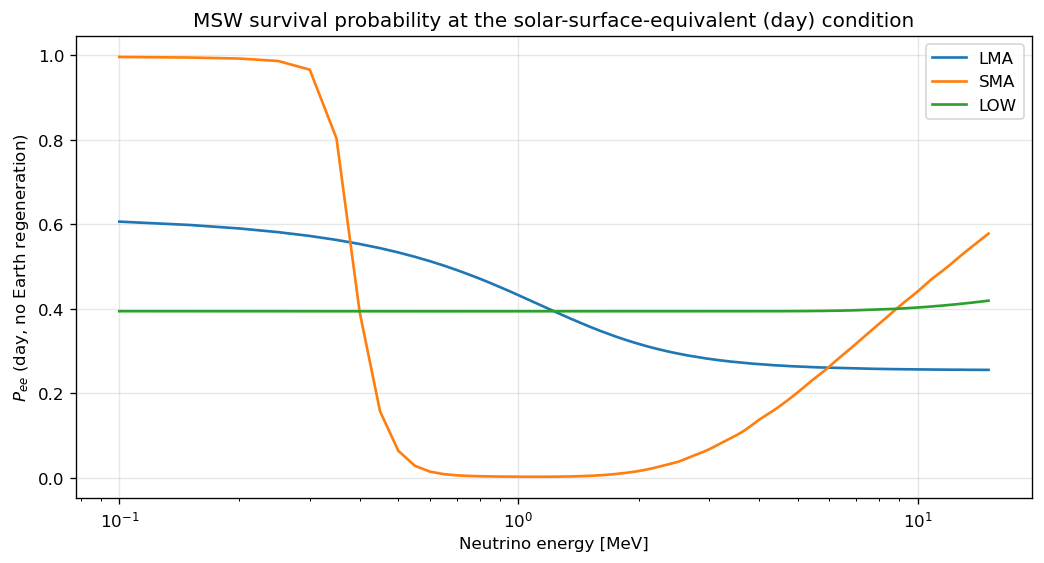

v:\output\external\bahcall\Bahcall_probability_fig4_1_msw_day_survival.png
LMA: P_ee(day) at E=0.100 MeV = 0.6061   at E=15.050 MeV = 0.2552
SMA: P_ee(day) at E=0.100 MeV = 0.9958   at E=15.050 MeV = 0.5778
LOW: P_ee(day) at E=0.100 MeV = 0.3941   at E=15.050 MeV = 0.4190


In [20]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
for name, df in msw.items():
    ax.plot(df["E_MeV"], df["Day"], lw=1.6, label=name)
ax.set_xscale("log")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"$P_{ee}$ (day, no Earth regeneration)")
ax.set_title("MSW survival probability at the solar-surface-equivalent (day) condition")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("Bahcall_probability_fig4_1_msw_day_survival.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for name, df in msw.items():
    print(f"{name}: P_ee(day) at E={df['E_MeV'].iloc[0]:.3f} MeV = {df['Day'].iloc[0]:.4f}   "
          f"at E={df['E_MeV'].iloc[-1]:.3f} MeV = {df['Day'].iloc[-1]:.4f}")

### 4.2 Earth Regeneration: Day versus Night

For the (currently favoured) LMA solution, the day, day+night average, and
night survival probabilities are compared directly, together with the
resulting day/night asymmetry $A_{ND}=(P_{\rm night}-P_{\rm day})/P_{\rm day}$.

**Expected results:** the night curve should sit above the day curve at
low-to-intermediate energy (Earth regeneration partially restores $\nu_e$),
with the two converging at high energy where Earth matter effects on 8B-scale
neutrinos are small for LMA parameters.

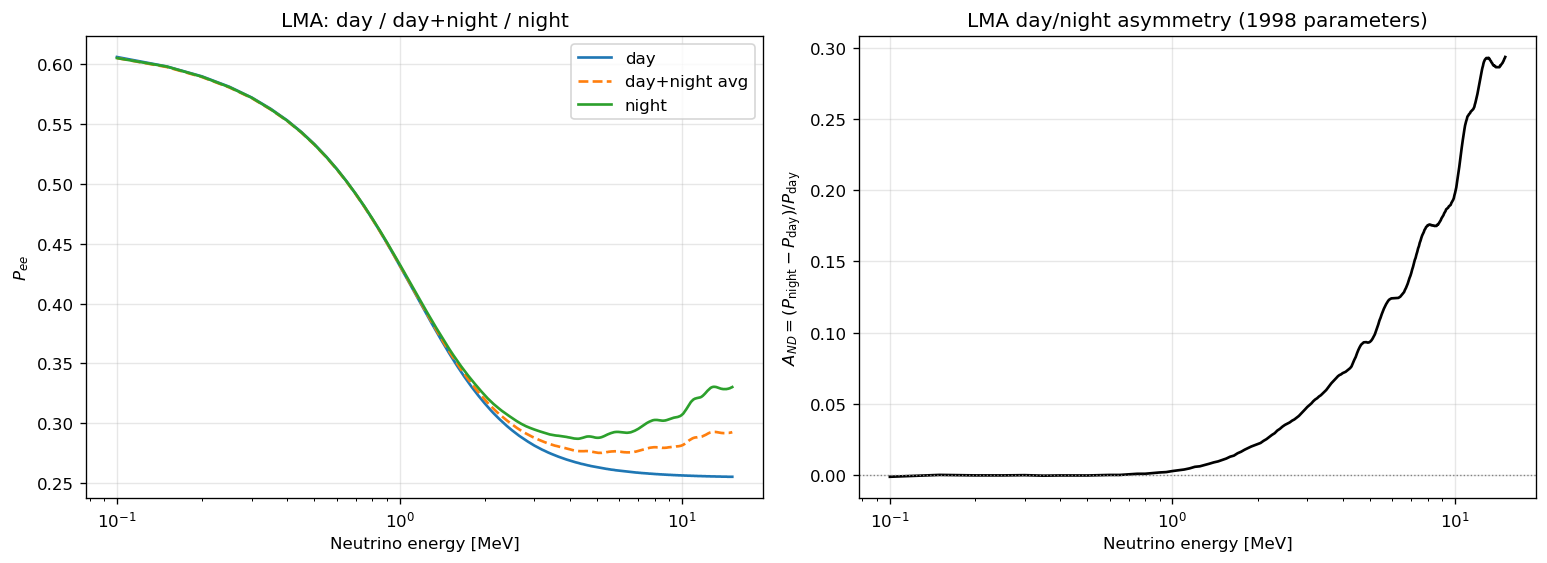

v:\output\external\bahcall\Bahcall_probability_fig4_2_lma_day_night.png
max day/night asymmetry (LMA, 1998 parameters): 0.2939 at E=15.05 MeV


In [21]:
lma = msw["LMA"]
asymmetry = (lma["Night"] - lma["Day"]) / lma["Day"]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(lma["E_MeV"], lma["Day"], lw=1.6, label="day")
axes[0].plot(lma["E_MeV"], lma["DayNight"], lw=1.6, ls="--", label="day+night avg")
axes[0].plot(lma["E_MeV"], lma["Night"], lw=1.6, label="night")
axes[0].set_xscale("log")
axes[0].set_xlabel("Neutrino energy [MeV]")
axes[0].set_ylabel(r"$P_{ee}$")
axes[0].set_title("LMA: day / day+night / night")
axes[0].legend()

axes[1].plot(lma["E_MeV"], asymmetry, lw=1.6, color="black")
axes[1].axhline(0.0, color="gray", lw=0.8, ls=":")
axes[1].set_xscale("log")
axes[1].set_xlabel("Neutrino energy [MeV]")
axes[1].set_ylabel(r"$A_{ND}=(P_{\rm night}-P_{\rm day})/P_{\rm day}$")
axes[1].set_title("LMA day/night asymmetry (1998 parameters)")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("Bahcall_probability_fig4_2_lma_day_night.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print(f"max day/night asymmetry (LMA, 1998 parameters): {float(asymmetry.max()):.4f} "
      f"at E={float(lma.loc[asymmetry.idxmax(), 'E_MeV']):.2f} MeV")

## 5. Illustrative 8B and CNO Survival Probability Sets

### 5.1 Seven 8B Parameter Sets

`b8survival.tab` gives seven $(\Delta m^2,\sin^22\theta)$ pairs from the
small-mixing-angle region, with the first being the best fit to the data
available at the time.

**Expected results:** all seven should be close to the vacuum/no-oscillation
limit $P_{ee}\approx1$ at very low energy and drop toward the SMA resonance
dip at higher energy, with some spread between the seven curves reflecting
the parameter variations.

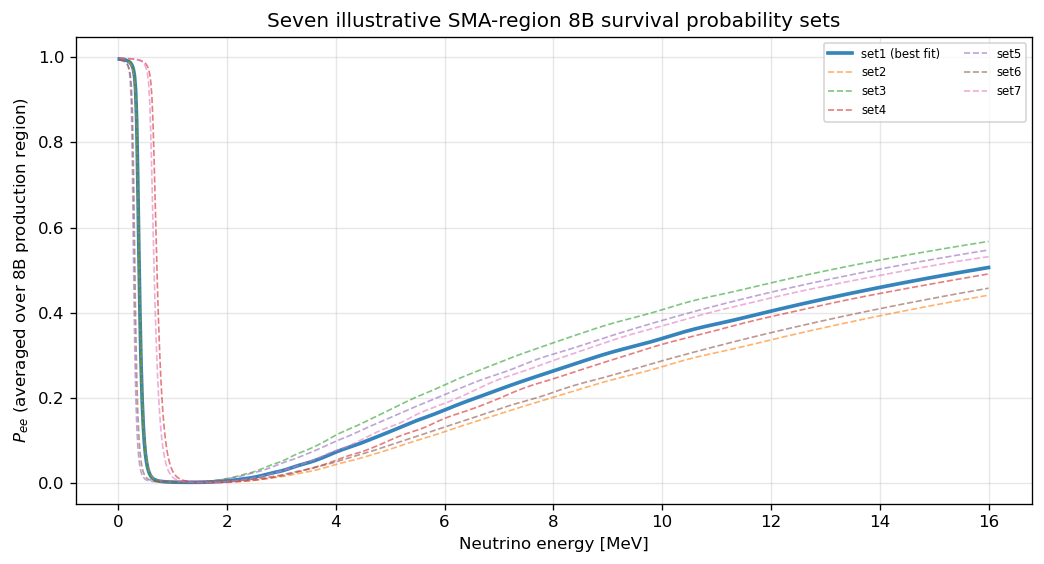

v:\output\external\bahcall\Bahcall_probability_fig5_1_b8survival_sets.png


In [22]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
for i, label in enumerate(SPECIES_B8):
    style = "-" if i == 0 else "--"
    lw = 2.2 if i == 0 else 1.0
    tag = f"{label} (best fit)" if i == 0 else label
    ax.plot(b8survival["E_MeV"], b8survival[label], style, lw=lw, alpha=0.9 if i == 0 else 0.6, label=tag)
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"$P_{ee}$ (averaged over 8B production region)")
ax.set_title("Seven illustrative SMA-region 8B survival probability sets")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
save_and_show("Bahcall_probability_fig5_1_b8survival_sets.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 CNO Survival Probability by Source Species

`cnosurvival.tab` gives $P_{ee}(E)$ for pp, 8B, 13N, and 15O neutrinos under
one specific all-CNO MSW parameter point.

**Expected results:** at a fixed energy, the different species need not
coincide exactly (they are produced over different radial regions of the
Sun and are therefore averaged over slightly different electron-density
paths), but the differences should be small compared to the overall
energy-driven trend.

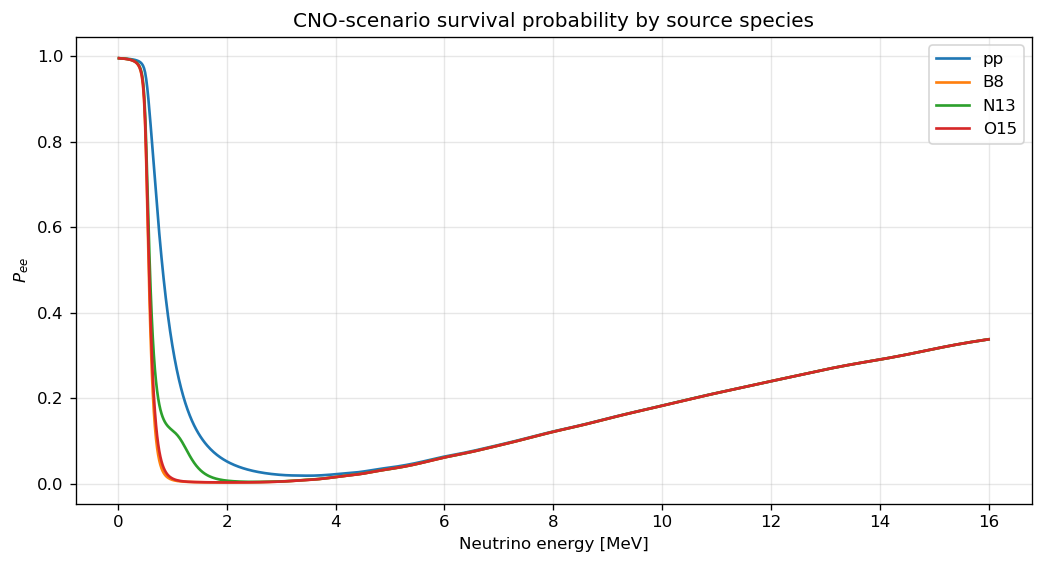

v:\output\external\bahcall\Bahcall_probability_fig5_2_cnosurvival_species.png
max spread across species (E <= 0.42 MeV, where all four are populated): 0.0205


In [23]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
for species in ["pp", "B8", "N13", "O15"]:
    ax.plot(cnosurvival["E_MeV"], cnosurvival[species], lw=1.6, label=species)
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel(r"$P_{ee}$")
ax.set_title("CNO-scenario survival probability by source species")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("Bahcall_probability_fig5_2_cnosurvival_species.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

overlap_mask = cnosurvival["E_MeV"] <= 0.42
spread = (cnosurvival.loc[overlap_mask, ["pp", "B8", "N13", "O15"]]).max(axis=1) - (cnosurvival.loc[overlap_mask, ["pp", "B8", "N13", "O15"]]).min(axis=1)
print(f"max spread across species (E <= 0.42 MeV, where all four are populated): {float(spread.max()):.4f}")

## 6. Undistorted Neutrino Production Spectra

### 6.1 8B Spectrum with Uncertainty Band

`b8spectrum.txt` gives the best-estimate 8B production spectrum together
with its $\pm3\sigma$ uncertainty band.

**Expected results:** a smooth, single-peaked spectrum extending to roughly
15 MeV, with the uncertainty band narrow near the peak and widening toward
the endpoints.

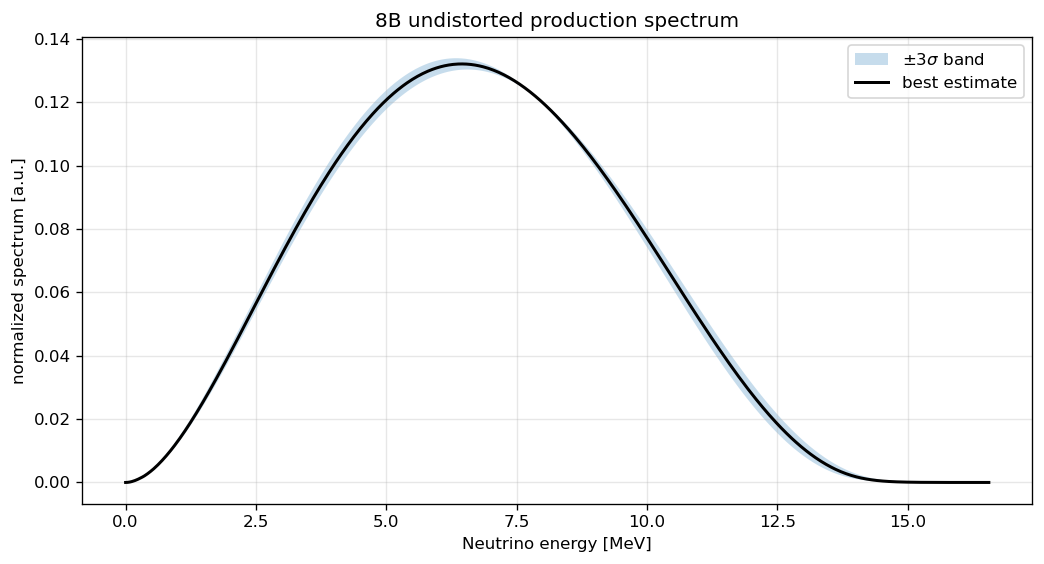

v:\output\external\bahcall\Bahcall_probability_fig6_1_b8_production_spectrum.png
8B spectrum peaks at E=6.44 MeV, endpoint at E=16.56 MeV


In [24]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.fill_between(b8spectrum["E_MeV"], b8spectrum["minus3sigma"], b8spectrum["plus3sigma"], alpha=0.25, label=r"$\pm3\sigma$ band")
ax.plot(b8spectrum["E_MeV"], b8spectrum["best"], lw=1.8, color="black", label="best estimate")
ax.set_xlabel("Neutrino energy [MeV]")
ax.set_ylabel("normalized spectrum [a.u.]")
ax.set_title("8B undistorted production spectrum")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("Bahcall_probability_fig6_1_b8_production_spectrum.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

peak_row = b8spectrum.loc[b8spectrum["best"].idxmax()]
print(f"8B spectrum peaks at E={peak_row['E_MeV']:.2f} MeV, endpoint at E={float(b8spectrum['E_MeV'].max()):.2f} MeV")

### 6.2 pp Spectrum

`ppenergytab` stores a single $(q, P(q))$ curve wrapped across four
side-by-side column pairs to fit a narrow printed table; `read_wrapped_pp_spectrum`
reconstructs the single continuous curve.

**Expected results:** a broad spectrum rising from zero, peaking around
0.3 MeV, and falling back to zero at the pp endpoint (~0.42 MeV).

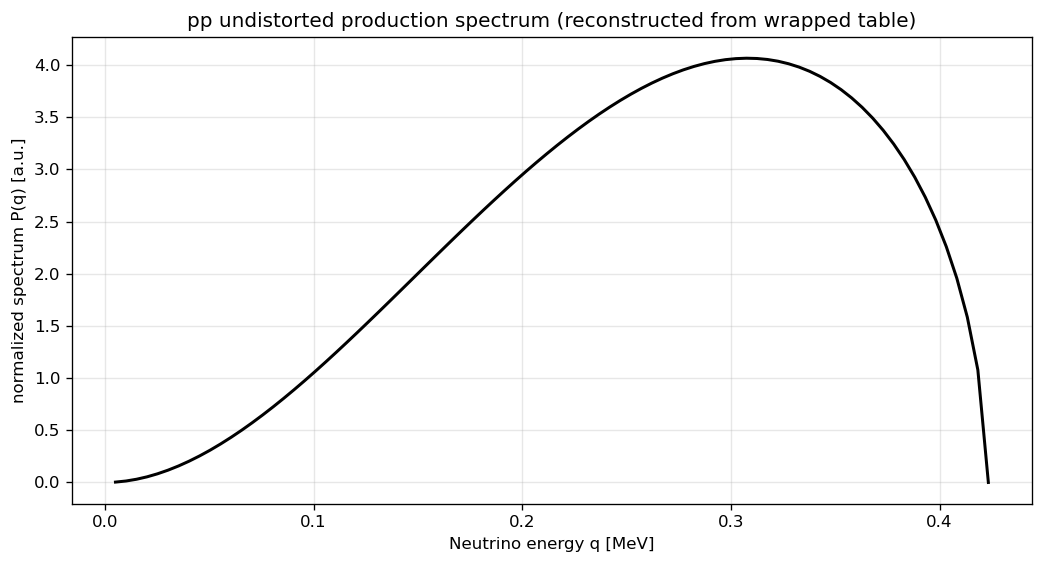

v:\output\external\bahcall\Bahcall_probability_fig6_2_pp_production_spectrum.png
pp spectrum peaks at q=0.3075 MeV, endpoint at q=0.4234 MeV


In [25]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(ppspectrum["q_MeV"], ppspectrum["P_q"], lw=1.8, color="black")
ax.set_xlabel("Neutrino energy q [MeV]")
ax.set_ylabel("normalized spectrum P(q) [a.u.]")
ax.set_title("pp undistorted production spectrum (reconstructed from wrapped table)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("Bahcall_probability_fig6_2_pp_production_spectrum.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

peak_row = ppspectrum.loc[ppspectrum["P_q"].idxmax()]
print(f"pp spectrum peaks at q={peak_row['q_MeV']:.4f} MeV, endpoint at q={float(ppspectrum['q_MeV'].max()):.4f} MeV")

### 6.3 CNO and hep Spectra

**Expected results:** 13N, 15O, 17F should each show a single broad peak with
endpoints below ~2 MeV; hep should extend much further, out to ~19 MeV
(a long high-energy tail relevant for backgrounds above the 8B endpoint).

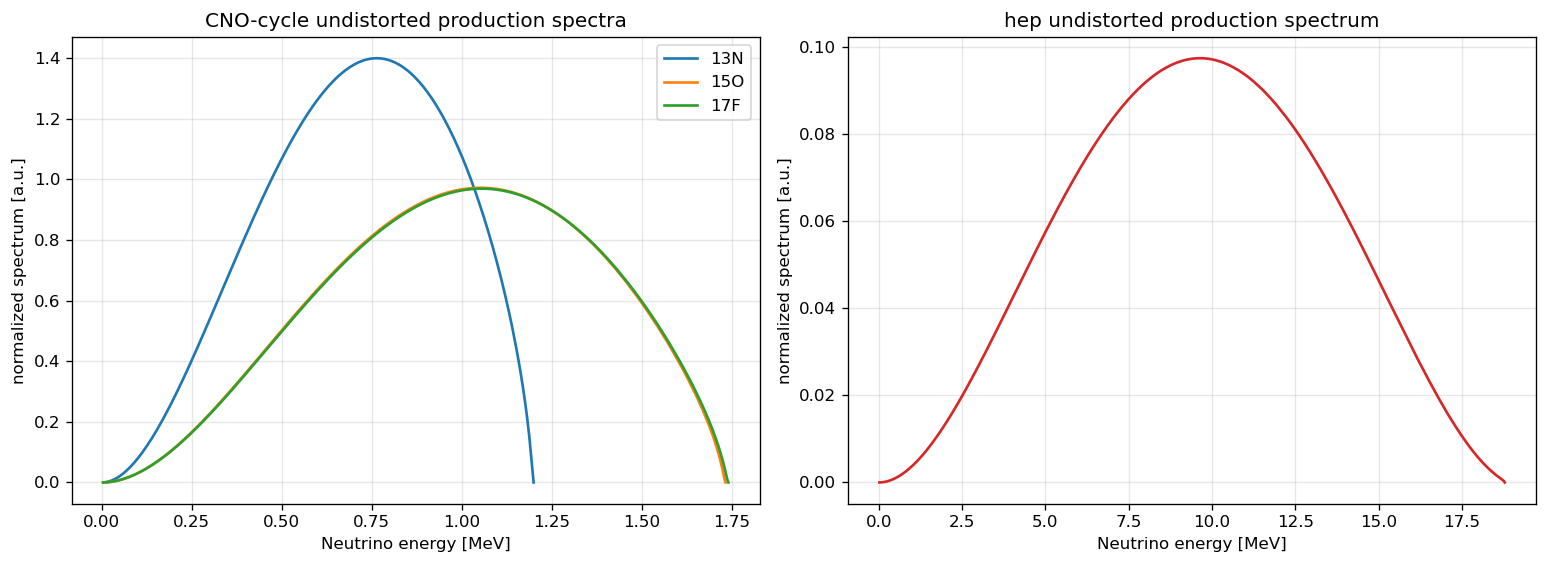

v:\output\external\bahcall\Bahcall_probability_fig6_3_cno_hep_production_spectra.png
13N : endpoint at E=1.199 MeV
15O : endpoint at E=1.732 MeV
17F : endpoint at E=1.740 MeV
hep : endpoint at E=18.784 MeV


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

for name, df in [("13N", n13spectrum), ("15O", o15spectrum), ("17F", f17spectrum)]:
    axes[0].plot(df["E_MeV"], df["spectrum"], lw=1.6, label=name)
axes[0].set_xlabel("Neutrino energy [MeV]")
axes[0].set_ylabel("normalized spectrum [a.u.]")
axes[0].set_title("CNO-cycle undistorted production spectra")
axes[0].legend()

axes[1].plot(hepspectrum["E_MeV"], hepspectrum["spectrum"], lw=1.6, color="C3")
axes[1].set_xlabel("Neutrino energy [MeV]")
axes[1].set_ylabel("normalized spectrum [a.u.]")
axes[1].set_title("hep undistorted production spectrum")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("Bahcall_probability_fig6_3_cno_hep_production_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for name, df in [("13N", n13spectrum), ("15O", o15spectrum), ("17F", f17spectrum), ("hep", hepspectrum)]:
    print(f"{name:4s}: endpoint at E={float(df['E_MeV'].max()):.3f} MeV")

## 7. Combining Production Spectrum and Survival Probability

Multiplying the undistorted 8B production spectrum (Section 6.1) by the LMA
day survival probability (Section 4.1), interpolated onto the spectrum's
energy grid, gives an illustrative *oscillated* spectrum shape -- the closest
this dataset can reconstruct to "what the production spectrum looks like by
the time it reaches the solar surface, after mass-basis decoherence".

**Expected results:** since $P_{ee}({\rm LMA,\ day})$ varies relatively slowly
with energy over the 8B range compared to the spectrum shape itself, the
oscillated spectrum should look like a mildly suppressed and slightly
reshaped version of the original, not a dramatically different curve.

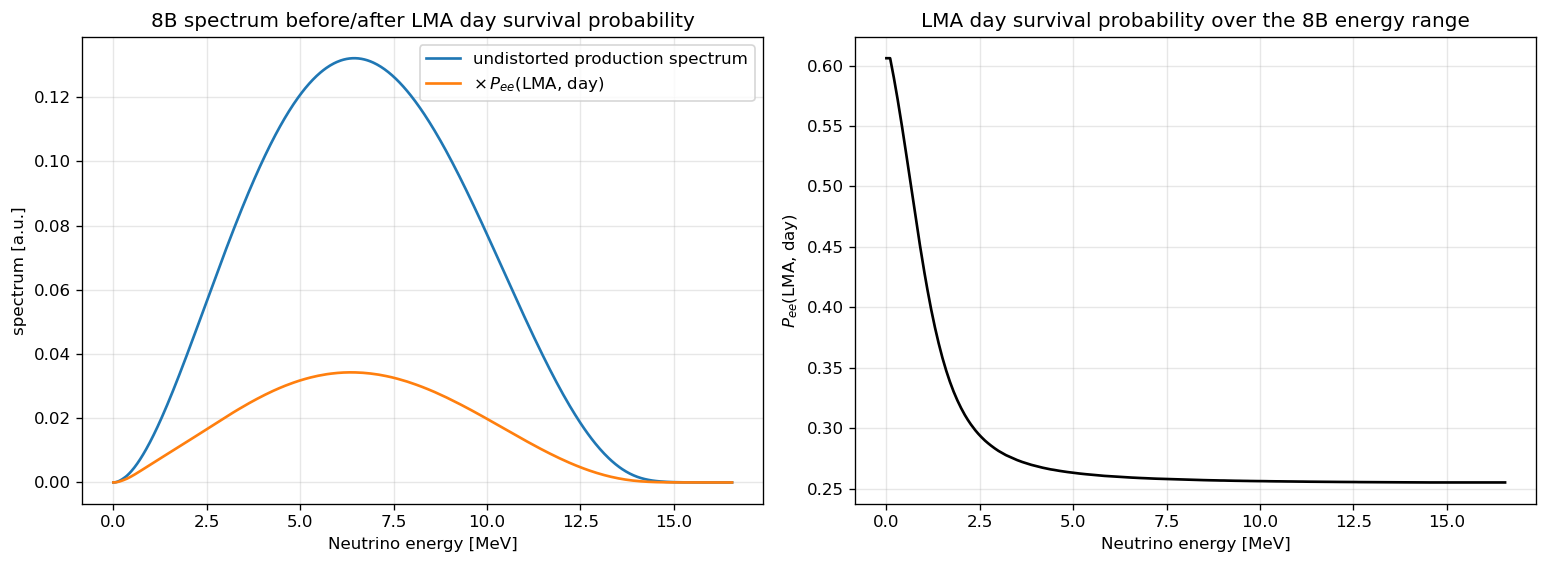

v:\output\external\bahcall\Bahcall_probability_fig7_1_oscillated_b8_spectrum.png
integrated suppression from LMA day survival probability over the 8B spectrum: 0.2660
(equivalently, an effective energy-averaged CC-like survival probability of 0.2660 for this illustrative combination)


In [28]:
p_ee_on_b8_grid = np.interp(b8spectrum["E_MeV"], lma["E_MeV"], lma["Day"])
oscillated_best = b8spectrum["best"] * p_ee_on_b8_grid

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(b8spectrum["E_MeV"], b8spectrum["best"], lw=1.6, label="undistorted production spectrum")
axes[0].plot(b8spectrum["E_MeV"], oscillated_best, lw=1.6, label=r"$\times\,P_{ee}$(LMA, day)")
axes[0].set_xlabel("Neutrino energy [MeV]")
axes[0].set_ylabel("spectrum [a.u.]")
axes[0].set_title("8B spectrum before/after LMA day survival probability")
axes[0].legend()

axes[1].plot(b8spectrum["E_MeV"], p_ee_on_b8_grid, lw=1.6, color="black")
axes[1].set_xlabel("Neutrino energy [MeV]")
axes[1].set_ylabel(r"$P_{ee}$(LMA, day)")
axes[1].set_title("LMA day survival probability over the 8B energy range")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("Bahcall_probability_fig7_1_oscillated_b8_spectrum.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

norm_ratio = float(numpy_trapezoid(oscillated_best, b8spectrum["E_MeV"]) / numpy_trapezoid(b8spectrum["best"], b8spectrum["E_MeV"]))
print(f"integrated suppression from LMA day survival probability over the 8B spectrum: {norm_ratio:.4f}")
print(f"(equivalently, an effective energy-averaged CC-like survival probability of {norm_ratio:.4f} for this illustrative combination)")

## 8. Summary

The local `data/external/Bahcall` files (extended in this notebook beyond
`Bahcall_EDA.ipynb`) provide 1998-era $P_{ee}(E)$ survival-probability tables
for the LMA, SMA, and LOW MSW solutions (Bahcall, Krastev, Smirnov 1998,
`hep-ph/9807216`), illustrative 8B and CNO survival-probability sets, and
undistorted production-energy spectra for 8B, pp, the CNO-cycle species, and
hep (8B spectrum: Bahcall et al. 1996, `nucl-th/9601044`).

The "Day" column of the MSW tables is the closest tabulated equivalent to a
survival probability "at the solar surface" available from this dataset: it
excludes Earth regeneration but already includes averaging over the
production-point distribution and propagation through the solar electron
density. Section 4 confirmed the expected qualitative behaviour of all three
1998 solutions and the day/night asymmetry for LMA (the solution later
confirmed correct); Section 7 combined an undistorted production spectrum
with a survival probability for the first time in this pair of notebooks,
illustrating how the two ingredients this thesis treats separately
(`medium.solar` production/propagation and the underlying oscillation
probability machinery) combine into an observable spectrum shape.

These tables are historical/pedagogical reference points rather than current
best-fit inputs (SMA and LOW are excluded by modern data); for validation
against this project's own analytical pipeline, compare against
`medium.vacuum.probability.pvacuum` and `medium.solar.probability.solar_flux_mass`
using modern oscillation parameters, as already done in
`notebooks/diagnostic/vacuum/diagnostic1_vacuum_propagation_flux.ipynb`.